In [45]:
from dataclasses import dataclass, field
import numpy as np
import matplotlib.pyplot as plt
from typing import List, Tuple

# Chatbot Optimization Model
Finds optimal depth S* that maximizes expected value $V_{\text{bot}}(S)$.

### 1. Data Structure for the Model

We first create a data structure for how hyperparameters of:
* $\vec{\rho}$ for a list of the conditional probabilities to do a certain task $S$,
    * For this, I assumed that $\vec{\rho} = [0.40, 0.20, 0.20, 0.15, 0.10, 0.07, 0.05, 0.03, 0.02, 0.01]$.

    Look to a hazard rate. A formalization of the way to select the numbers.
* $\vec{\tau}$ for a list of how long it takes to do a certain task $S$.
    * I assumed that $\vec{\tau} = [1.0,  1.0,  1.5,  1.8,  2.0,  2.2,  2.5,  2.8,  3.0,  3.5]$.
    * Look at the literature and how to get the length for the tau. This would be a free variable. Find a representative example or a breath of task. 
* $r$ for the reward if chatbot resolves the issue, 
* $c_c$ for the cost of cold transferring, 
* $V_\text{agent}$ for the value of the human agent handling the issue,
* $R^*$ for the time cost rate (so the value lost per unit time),
* $a_\text{bot}$ for the training cost scale parameter,
* $b_\text{bot}$ for the training cost convexity parameter


In [46]:
@dataclass
class Params:
    rho: list
    tau: list
    r: float
    cc: float
    V_agent: float
    R_star: float
    a_bot: float
    b_bot: float

### 2. Accessory Functions Needed

We will then develop the core functions for the model, which are all dependent on the chatbot reaching some task S. Namely, the functions are to determine:
1. Overall chatbot sucess probability for reaching until some task $S$
$$p_\text{succ}^\text{bot}(S) = 1 - \prod_{x=1}^{S}(1 - \rho_x)$$
2. Total time cost for reaching until some task $S$
$$\text{Total Time Cost} = \sum_{x=1}^{S} \tau_x$$
3. Training/development cost for reaching until some task $S$
$$ c_\text{bot}(S) = a_\text{bot} \cdot \big( 100 * p_\text{succ}^\text{bot}(S) \big)^{b_\text{bot}}$$
4. Expected value of the chatbot policy for reaching until some task $S$
$$ V_\text{bot}(S) =  p_\text{succ}^\text{bot}(S) \cdot r + \big(1 -  p_\text{succ}^\text{bot}(S) \big) \big(V_\text{agent} - c_c) - R^* \cdot \sum_{x=1}^S \tau_x -c_\text{bot}(S)$$

In [53]:
def p_succ(S: int, rho: List[float]) -> float:
    """
    Overall chatbot success probability for depth S.

    p_succ(S) = 1 - prod_{x=1}^{S} (1 - rho_x)

    Args:
        S   : depth (number of steps attempted, 1-indexed)
        rho : list of step-level success probabilities

    Returns:
        Scalar probability in [0, 1]
    """
    if S == 0:
        return 0.0
    failure_prob = 1.0
    for x in range(S):
        failure_prob *= (1.0 - rho[x])
    return 1.0 - failure_prob

def total_time(S: int, tau: List[float]) -> float:
    """
    Total time cost for running S steps.

    T(S) = sum_{x=1}^{S} tau_x

    Args:
        S   : depth
        tau : list of per-step time costs

    Returns:
        Scalar total time
    """
    return sum(tau[:S])

def c_bot(S: int, rho: List[float], a_bot: float, b_bot: float) -> float:
    """
    Training/development cost, convex in p_succ.

    c_bot(S) = a_bot * (100 * p_succ(S))^b_bot

    Args:
        S     : depth
        rho   : step-level success probs
        a_bot : scale parameter
        b_bot : convexity parameter

    Returns:
        Scalar cost
    """
    ps = p_succ(S, rho)

    # exponential convex function
    # return a_bot * (100.0 * ps) ** b_bot
    
    # parabolic convex function
    return a_bot * (10 * ps) ** 2 + b_bot

def V_bot(S: int, p: Params) -> float:
    """
    Expected value of chatbot policy at depth S.

    V_bot(S) = p_succ(S) * r
             + (1 - p_succ(S)) * (V_agent - c_c)
             - R_star * T(S)
             - c_bot(S)

    Args:
        S      : depth
        params : model parameters dict

    Returns:
        Scalar expected value
    """
    ps   = p_succ(S, p.rho)
    T    = total_time(S, p.tau)
    cost = c_bot(S, p.rho, p.a_bot, p.b_bot)

    return (
        ps * p.r
        + (1.0 - ps) * (p.V_agent - p.cc)
        - p.R_star * T
        - cost
    )


### 3. Optimization

$$ S^* = \arg \max_{S} V_\text{bot} (S)$$

In [54]:
def optimize(p: Params) -> Tuple[int, float, List[float]]:
    """
    Find optimal depth S* = argmax_S V_bot(S).

    Evaluates all feasible depths S = 1, ..., max_S.

    Args:
        params : model parameters dict

    Returns:
        (S_star, V_star, all_values)
        S_star    : optimal depth
        V_star    : optimal expected value
        all_values: list of V_bot(S) for S = 0, 1, ..., max_S
    """
    max_S = len(p.rho)
    values = [V_bot(S, p) for S in range(max_S + 1)]

    # S=0 means no chatbot at all (baseline)
    S_star = int(np.argmax(values[1:]) + 1)  # search over S >= 1
    V_star = values[S_star]

    return S_star, V_star, values

In [55]:
def print_summary(p: Params) -> None:
    """Prints a full summary of model results."""
    max_S  = len(p.rho)

    S_star, V_star, values = optimize(p)

    print("=" * 60)
    print("CHATBOT OPTIMIZATION MODEL — RESULTS")
    print("=" * 60)

    print("\n--- Parameters ---")
    print(f"  Reward if resolved   (r)      : {p.r}")
    print(f"  Cold transfer cost   (c_c)    : {p.cc}")
    print(f"  Human agent value    (V_agent): {p.V_agent}")
    print(f"  Time cost rate       (R*)     : {p.R_star}")
    print(f"  Training cost (a, b)          : {p.a_bot}, {p.b_bot}")

    print("\n--- Step-level Profile ---")
    print(f"  {'S':>4}  {'rho_x':>8}  {'tau_x':>8}  {'p_succ':>8}  {'T(S)':>8} {'TimeCost':>10}  {'TrainCost':>10}  {'V_bot':>10}")
    print("  " + "-" * 90)
    for S in range(1, max_S + 1):
        ps  = p_succ(S, p.rho)
        T   = total_time(S, p.tau)
        V   = values[S]

        time_cost  = p.R_star * T
        train_cost = c_bot(S, p.rho, p.a_bot, p.b_bot)   

        marker = " <-- OPTIMAL" if S == S_star else ""
        print(f"  {S:>4}  {p.rho[S-1]:>8.3f}  {p.tau[S-1]:>8.2f}  {ps:>8.4f}  {T:>8.2f}  {time_cost:>10.4f}  {train_cost:>10.4f}  {V:>10.4f}{marker}")

    print("\n--- Optimal Policy ---")
    print(f"  S*        = {S_star}")
    print(f"  p_succ*   = {p_succ(S_star, p.rho):.4f}  ({100*p_succ(S_star, p.rho):.2f}%)")
    print(f"  T*        = {total_time(S_star, p.tau):.2f}")
    print(f"  V_bot*    = {V_star:.4f}")
    print("=" * 60)


def plot_results(p: Params, save_path: str = None) -> None:
    """
    Plots V_bot(S) across all depths, highlighting S*.
    """
    rho   = p.rho
    max_S = len(rho)

    S_star, V_star, values = optimize(p)

    S_range = list(range(1, max_S + 1))
    V_range = values[1:]
    ps_range = [p_succ(S, rho) for S in S_range]

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle("Chatbot Optimization Model", fontsize=14, fontweight="bold")

    # --- Left: V_bot(S) ---
    ax = axes[0]
    ax.plot(S_range, V_range, "o-", color="#3266ad", linewidth=2, markersize=5, label="V_bot(S)")
    ax.axvline(S_star, color="#e04f3a", linestyle="--", linewidth=1.5, label=f"S* = {S_star}")
    ax.scatter([S_star], [V_star], color="#e04f3a", s=100, zorder=5)
    ax.set_xlabel("Task S (steps allowed)", fontsize=12)
    ax.set_ylabel("Expected Value V_bot(S)", fontsize=12)
    ax.set_title("Expected Value vs. Number of Tasks")
    ax.legend()
    ax.grid(True, alpha=0.3)

    # --- Right: p_succ(S) ---
    ax2 = axes[1]
    ax2.plot(S_range, [p * 100 for p in ps_range], "s-", color="#2a9d6e",
             linewidth=2, markersize=5, label="p_succ(S)")
    ax2.axvline(S_star, color="#e04f3a", linestyle="--", linewidth=1.5, label=f"S* = {S_star}")
    ax2.set_xlabel("Task S (steps allowed)", fontsize=12)
    ax2.set_ylabel("Success Probability (%)", fontsize=12)
    ax2.set_title("Cumulative Success Probability vs. Number of Tasks")
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"  Plot saved to: {save_path}")
    else:
        plt.show()


# Actual Execution

In [56]:
p = Params(
    rho=     [0.40, 0.20, 0.20, 0.15, 0.10, 0.07, 0.05, 0.03, 0.02, 0.01],
    tau=     [1.0,  1.0,  1.5,  1.8,  2.0,  2.2,  2.5,  2.8,  3.0,  3.5],
    r=       100.0,
    cc=      10.0,
    V_agent= 60.0,
    R_star=  2.0,
    a_bot=   0.05,
    b_bot=   0.5,
)

In [57]:
print_summary(p)

CHATBOT OPTIMIZATION MODEL — RESULTS

--- Parameters ---
  Reward if resolved   (r)      : 100.0
  Cold transfer cost   (c_c)    : 10.0
  Human agent value    (V_agent): 60.0
  Time cost rate       (R*)     : 2.0
  Training cost (a, b)          : 0.05, 0.5

--- Step-level Profile ---
     S     rho_x     tau_x    p_succ      T(S)   TimeCost   TrainCost       V_bot
  ------------------------------------------------------------------------------------------
     1     0.400      1.00    0.4000      1.00      2.0000      1.3000     66.7000
     2     0.200      1.00    0.5200      2.00      4.0000      1.8520     70.1480
     3     0.200      1.50    0.6160      3.50      7.0000      2.3973     71.4027 <-- OPTIMAL
     4     0.150      1.80    0.6736      5.30     10.6000      2.7687     70.3113
     5     0.100      2.00    0.7062      7.30     14.6000      2.9939     67.7181
     6     0.070      2.20    0.7268      9.50     19.0000      3.1412     64.1989
     7     0.050      2.50    

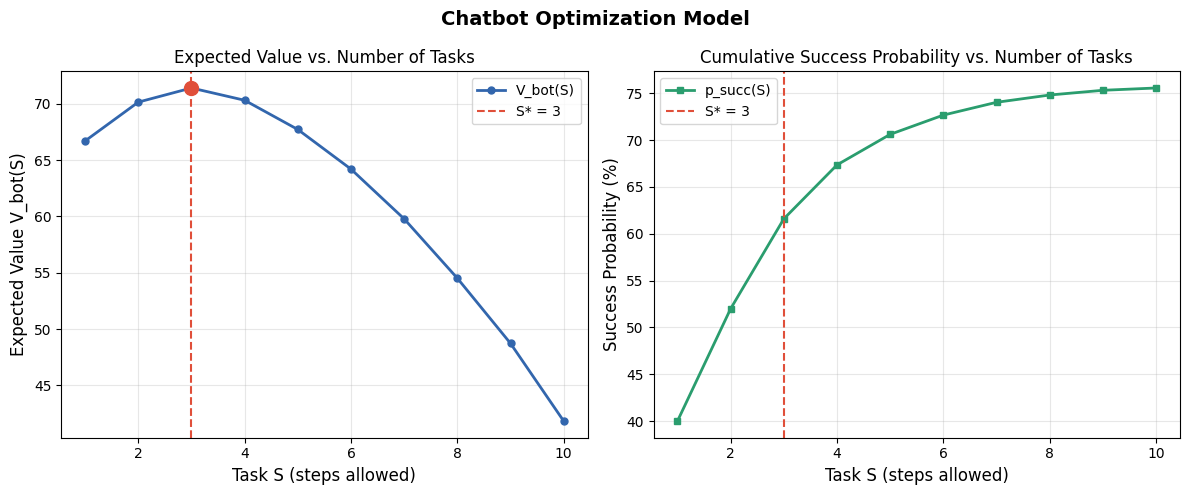

In [58]:
plot_results(p)